In [ ]:
!pip install datasets

In [3]:
# imports

import os
from dotenv import load_dotenv
from huggingface_hub import login
from datasets import load_dataset
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import numpy as np
import random
from pricer.items import Item
from pricer.parser import parse
load_dotenv(override=True)

True

In [3]:
# Log in to HuggingFace - if you get a "Note" about Environment variable being set, ignore it

hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


## Fix for Dataset Loading Error

To resolve this issue, downgrade the `datasets` library to a version that still supports Python dataset scripts and the `trust_remote_code` workflow.

```bash
pip install datasets==3.6.0
```

In [4]:
dataset = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_meta_Appliances", split="full", trust_remote_code=True)

In [ ]:
print(f"Number of Appliances: {len(dataset):,}")

In [15]:
max_price = None

for datapoint in dataset:
    price = datapoint.get("price")
    if price is not None:
        try:
            numeric_price = float(price)
            if (max_price is None) or (numeric_price > max_price):
                max_price = numeric_price
        except (ValueError, TypeError):
            continue  # skip if price is not convertible to float

print(f"The most expensive item is costs {max_price:,.2f}")


The most expensive item is costs 21,095.62


In [17]:
def load_items_from_dataset(dataset, category="Appliances"):
    """
    Load datapoints from the dataset into Item objects, filter for valid items.
    Uses tqdm progress bar if available.

    Args:
        dataset: The dataset to process.
        category (str): The category to pass to 'parse'.

    Returns:
        List of valid Item objects.
    """
    # tqdm with notebook mode causes "IProgress not found" error if ipywidgets/Jupyter are not up-to-date.
    # Use the stdlib progress bar as a workaround (or omit progress bar).
    try:
        from tqdm import tqdm
        iterable = tqdm(dataset)
    except ImportError:
        iterable = dataset

    items = [parse(datapoint, category) for datapoint in iterable]
    items = [item for item in items if item is not None]
    print(f"There are {len(items):,} items from {len(dataset):,} datapoints")
    return items

# Call the function to create 'items'
items = load_items_from_dataset(dataset, category="Appliances")

100%|██████████| 94327/94327 [00:28<00:00, 3304.08it/s]


There are 35,307 items from 94,327 datapoints


In [ ]:
max_price = 0
i = 0
# Find the maximum price among all items
for item in items:
    if item.price is not None and item.price > max_price:
        max_price = item.price

# Print the titles of items that have the maximum price
for item in items:
    if item.price == max_price:
        print(f"{i}. {item.title} - {item.price}\n\n")
    i += 1
    if i > len(items) - 10:
        break

print(f"The most expensive item costs {max_price}")


4150. EdgeStar KC3000SSTWIN Full Size Dual Tap Kegerator with Digital Display - Black and Stainless Steel - 999.0


4170. Robam 30” Range Hood |UNIQUE SLANTED BLACK GLASS DESIGN| Under-Cabinet or Wall Mount | Convenient Hands-Off Operation | Powerful Suction with Turbo Mode | Dishwasher Safe Baffle (ROBAM-A671) - 999.0


8704. ROBAM G413 30” Gas Cooktop Stove with 4 Italian-Made DEFENDI Burners (Pure Copper) | 20,000 BTU w/Flame Failure System, Matte Cast Iron Grates (Including Wok Grate) | Natural Gas Or LPG - 999.0


11677. EdgeStar CWB8420DZ 24 Inch Built-In Wine and Beverage Cooler - 999.0


12007. Pacific Trusteam Under Cabinet Hood SC8836BS Bundle with Pacific SUS304 Deflector Board - 999.0


14709. Avanti ERU240P3S ERU240 24" Electric Range Oven with Framed Glass Door, in Stainless Steel - 999.0


17253. FOTILE EMS9018 36" Wall-mount Range Hood | Touchscreen | 2 Speed-settings and Auto-Turbo Function | Delay Off Function | LED Light - 999.0


21105. SHARP Smart Dishwasher Works 

In [ ]:
i = len(items)
for item in items:
    i -= 1
    print(f"{i}. {price}")
    if i < len(items) - 10:
        break
    

In [25]:
items[0]

<WD12X10327 Rack Roller and stud assembly Kit (4 Pack) by AMI PARTS Replaces AP4980629 PS3486910 1811003 = $8.99>

In [33]:
print(items[0].full)

Rack Roller and stud assembly Kit (4 Pack) by AMI PARTS Replaces   1811003
['【PARTS NUMBER】The  dishwasher top rack wheels and stud assembly Kit （4 pcs）', '【SCOPE OF 】The dishwasher works with most top name brands,If you are not sure if part is correct, ask us in Customer questions & answers section or visiting the AMI PARTS storefront.We’re happy to help ensure you select the correct part for your Rack Roller and stud', '【 PART】, , , , , , , , , , , , ', '【FIXES SYMPTOMS】Door won’t close | Not cleaning dishes properly | Noisy | Door latch failure', '【QUALITY WARRANTY】The replacement part is made from durable high quality material and well-tested by manufacturer.For any reason you’re not satisfied,you can ask for a replacement or full refund']
{"Brand Name": "AMI PARTS", "Model Info": "", "Item Weight": "0.634 ounces", "Color": "White", "Material Type": "Plastic", "Date First Available": "July 14, 2019", "Brand": "AMI PARTS", "Material": "Plastic", "Model Name": " Rack Roller and stud 

In [23]:
prices = [item.price for item in items]
# print(prices)
lengths = [len(item.full) for item in items]

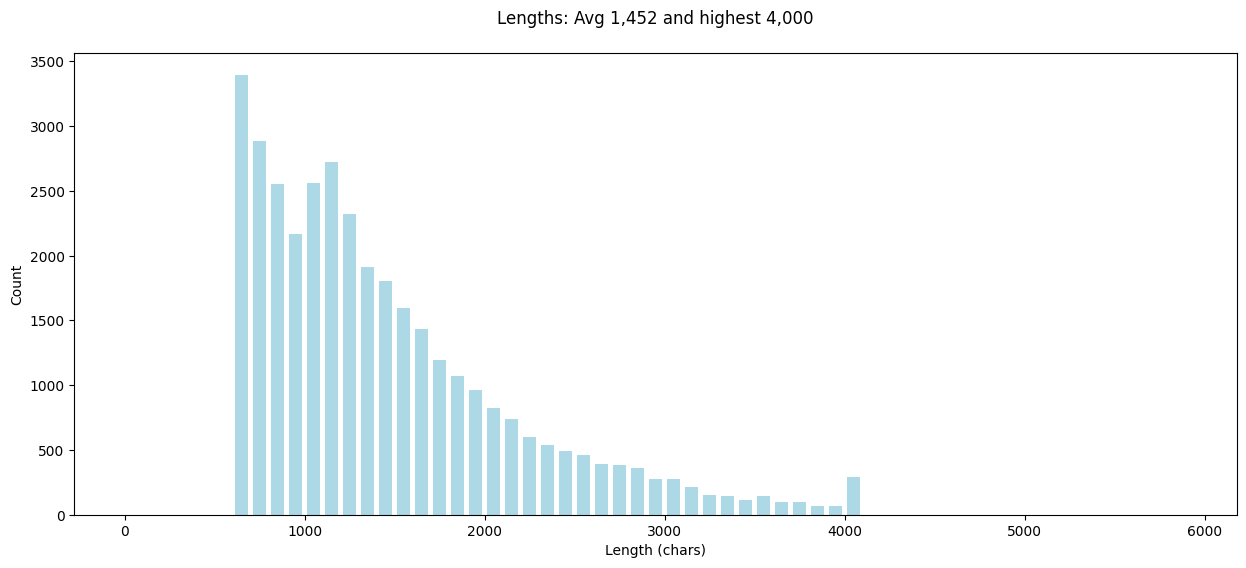

In [18]:
# Plot the distribution of lengths

plt.figure(figsize=(15, 6))
plt.title(f"Lengths: Avg {sum(lengths)/len(lengths):,.0f} and highest {max(lengths):,}\n")
plt.xlabel('Length (chars)')
plt.ylabel('Count')
plt.hist(lengths, rwidth=0.7, color="lightblue", bins=range(0, 6000, 100))
plt.show()

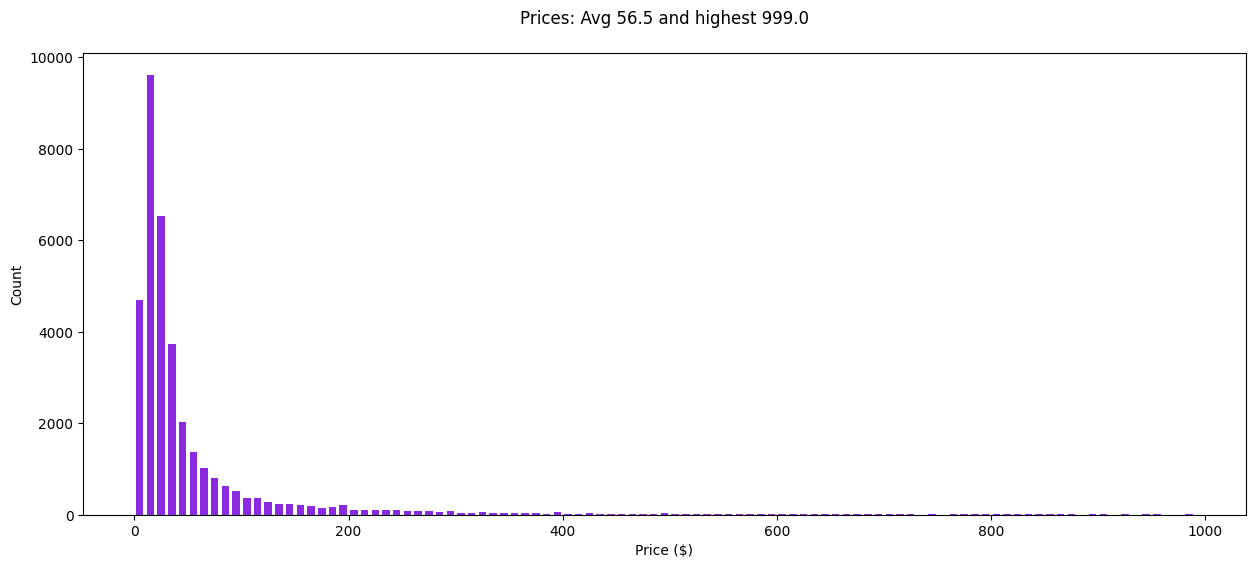

In [24]:
# Plot the distribution of prices

prices = [item.price for item in items]
plt.figure(figsize=(15, 6))
plt.title(f"Prices: Avg {sum(prices)/len(prices):,.1f} and highest {max(prices):,}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="blueviolet", bins=range(0, 1000, 10))
plt.show()

dict_keys(['Appliances'])


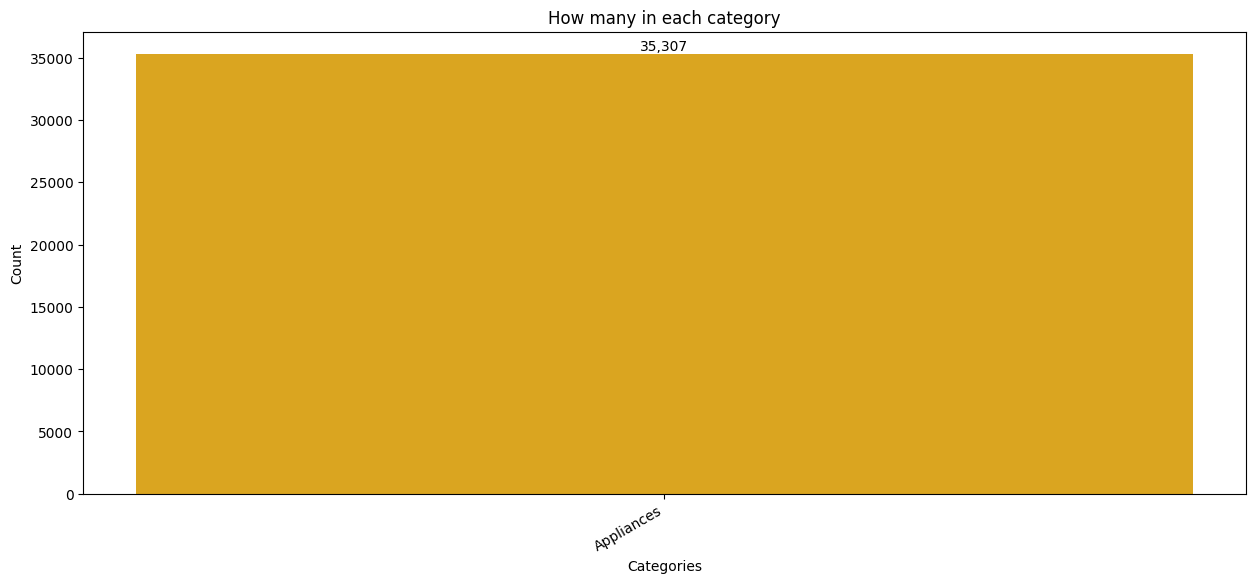

In [26]:
from collections import Counter
category_counts = Counter([item.category for item in items])

categories = category_counts.keys()
print(categories)
counts = [category_counts[category] for category in categories]

plt.figure(figsize=(15, 6))
plt.bar(categories, counts, color="goldenrod")
plt.title('How many in each category')
plt.xlabel('Categories')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')

for i, v in enumerate(counts):
    plt.text(i, v, f"{v:,}", ha='center', va='bottom')

plt.show()

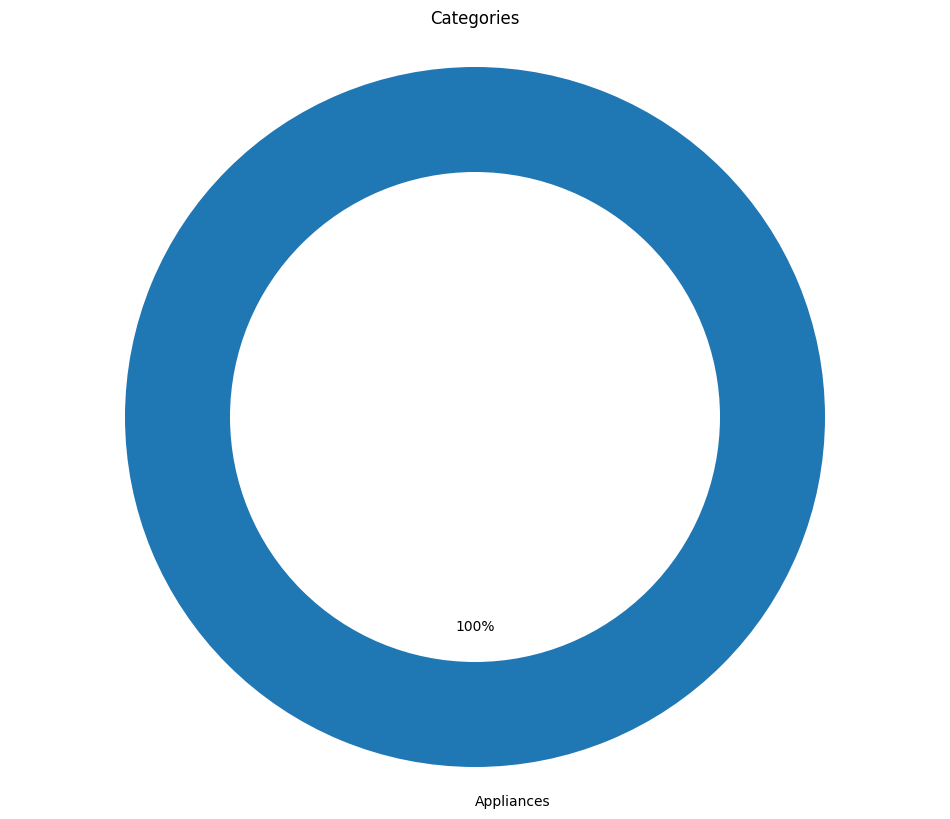

In [27]:
# Automotive still in the lead, but improved somewhat
# For another perspective, let's look at a pie

plt.figure(figsize=(12, 10))
plt.pie(counts, labels=categories, autopct='%1.0f%%', startangle=90)

# Add a circle at the center to create a donut chart (optional)
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title('Categories')

# Equal aspect ratio ensures that pie is drawn as a circle
plt.axis('equal')  

plt.show()

In [30]:
np.random.seed(42)

# SIZE = 820_000
SIZE = 10000

prices = np.array([it.price for it in items], dtype=float)
categories = np.array([it.category for it in items])
p = (prices - prices.min()) / (prices.max() - prices.min() + 1e-9)

w = p**2
w[categories == "Tools_and_Home_Improvement"] *= 0.5
w[categories == "Automotive"] *= 0.05

w = w / w.sum()
idx = np.random.choice(len(items), size=SIZE, replace=False, p=w)
sample = [items[i] for i in idx]

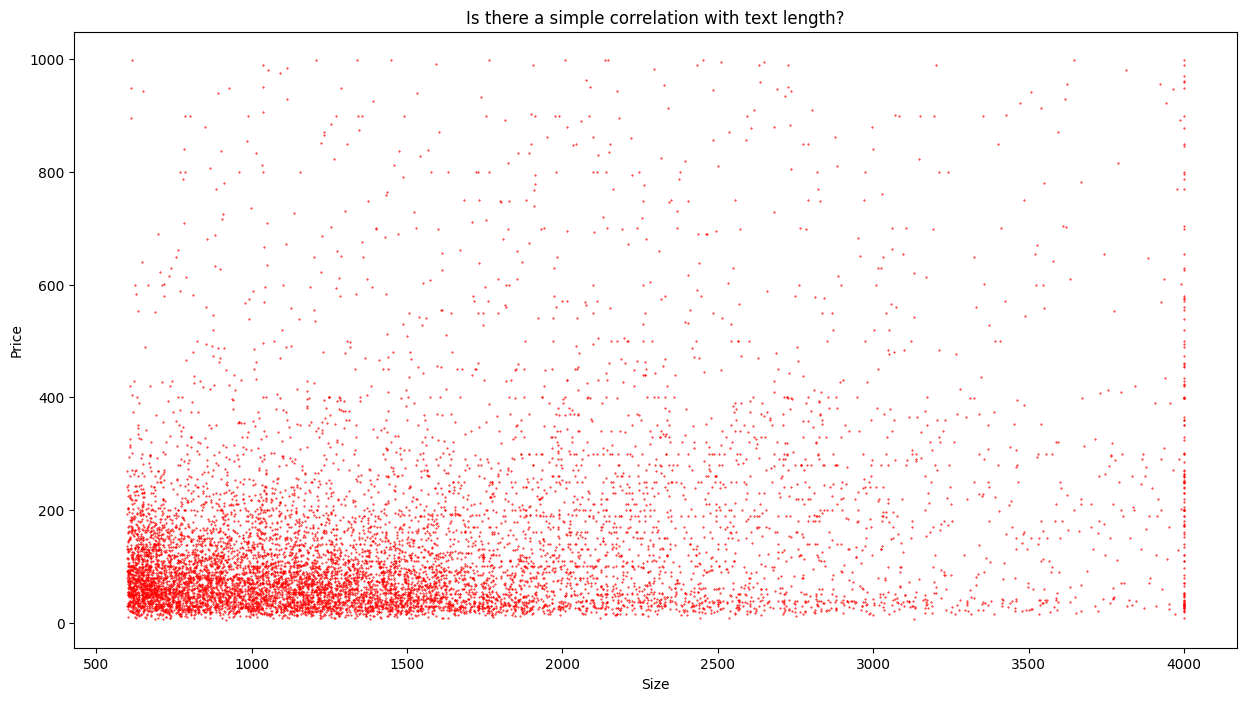

In [31]:
# How does the price vary with the character count?

sizes = [len(item.full) for item in sample]
prices = [item.price for item in sample]

# Create the scatter plot
plt.figure(figsize=(15, 8))
plt.scatter(sizes, prices, s=0.2, color="red")

# Add labels and title
plt.xlabel('Size')
plt.ylabel('Price')
plt.title('Is there a simple correlation with text length?')

# Display the plot
plt.show()

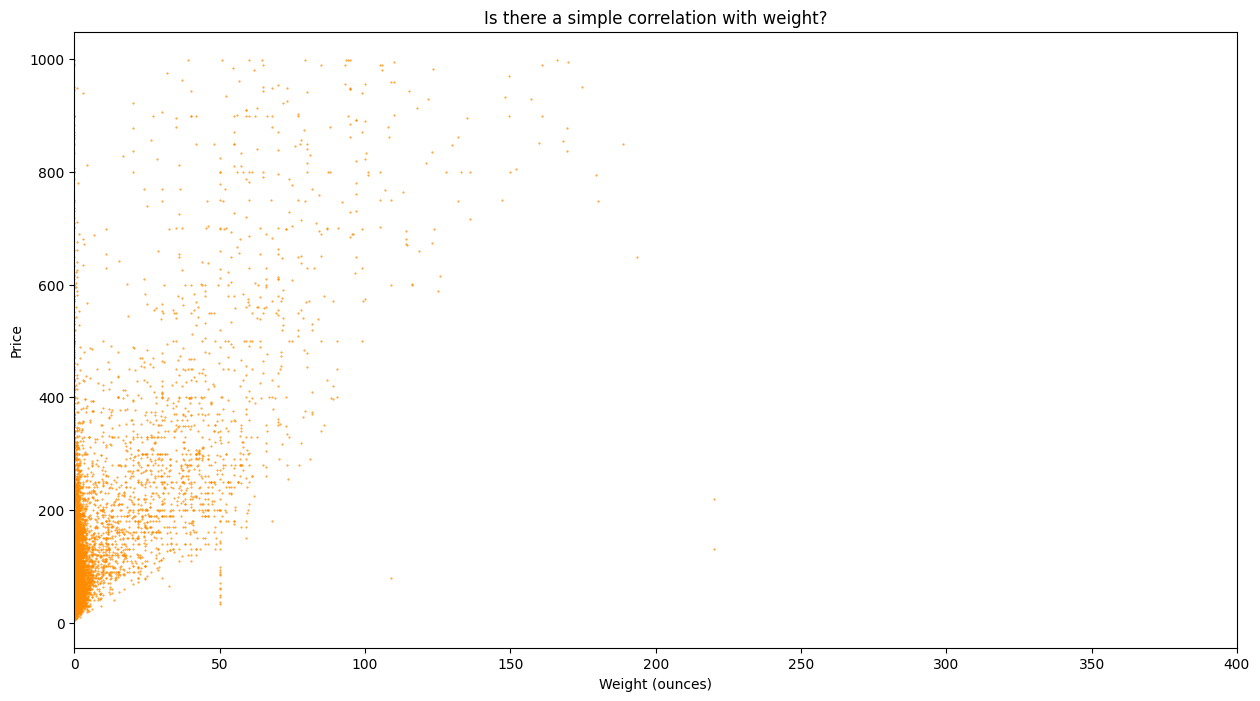

In [33]:
# How does the price vary with the weight?

ounces = [item.weight for item in sample]
prices = [item.price for item in sample]

# Create the scatter plot
plt.figure(figsize=(15, 8))
plt.scatter(ounces, prices, s=0.2, color="darkorange")

# Add labels and title
plt.xlabel('Weight (ounces)')
plt.ylabel('Price')
plt.xlim(0, 400)
plt.title('Is there a simple correlation with weight?')

# Display the plot
plt.show()

In [ ]:
username = "ed-donner"
full = f"{username}/items_raw_full"
lite = f"{username}/items_raw_lite"

train = sample[:800_000]
val = sample[800_000:810_000]
test = sample[810_000:]

Item.push_to_hub(full, train, val, test)

train_lite = train[:20_000]
val_lite = val[:1_000]
test_lite = test[:1_000]

Item.push_to_hub(lite, train_lite, val_lite, test_lite)